# 🔍 基金对比与筛选

## 本节目标

学会用数据筛选基金，而不是看广告和排行榜：
1. 多维度基金扫描（收益、回撤、夏普）
2. 深度对比你看中的几只基金
3. 读懂风险指标，避开坑
4. 理解「历史业绩不代表未来」的真正含义

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

from scripts.data.client import get_fund_nav, get_fund_ranking
from scripts.analysis.fund_scanner import calculate_metrics
from scripts.analysis.risk import risk_report, max_drawdown
from scripts.utils import viz

print("✅ 准备就绪")

✅ 准备就绪


## 1. 快速看排名（但要保持清醒）

排行榜告诉你过去谁涨得好，但**追涨的往往亏得最惨**。

In [8]:
# 查看各类型基金近期排名
for ftype in ["stock", "mix", "bond", "index"]:
    try:
        ranking = get_fund_ranking(fund_type=ftype, top_n=5)
        print(f"\n📊 {ftype} 型基金 Top 5:")
        display(ranking)
    except Exception as e:
        print(f"⚠️ {ftype}: {e}")

print("\n⚠️ 再次提醒: 短期排名靠前 ≠ 值得买！")


📊 stock 型基金 Top 5:


,code,name,return_1w,return_1m,return_3m,return_6m,return_1y,return_2y,return_3y
0,006502,财通集成电路产业股票A,2.64,32.48,48.91,46.97,232.53,264.86,234.48
1,006503,财通集成电路产业股票C,2.63,32.39,48.62,46.39,229.91,259.11,226.55
2,006265,红土创新新科技股票A,4.18,29.92,45.68,74.57,213.27,282.07,197.58
3,008382,融通产业趋势股票,2.31,34.61,53.32,68.70,196.26,193.00,146.99
4,001956,国联安科技动力,3.54,26.53,48.01,46.51,186.63,173.21,120.58



📊 mix 型基金 Top 5:


,code,name,return_1w,return_1m,return_3m,return_6m,return_1y,return_2y,return_3y
0,016370,信澳业绩驱动混合A,2.47,25.50,47.43,61.00,310.98,385.65,245.20
1,004320,前海开源沪港深乐享生活,3.37,37.60,59.37,111.59,310.78,384.14,181.98
2,016371,信澳业绩驱动混合C,2.46,25.43,47.21,60.53,308.53,379.96,239.09
3,022364,永赢科技智选混合发起A,1.48,25.39,33.30,39.93,298.54,NaN,NaN
4,008528,华泰柏瑞质量成长A,1.93,25.07,52.34,81.46,296.50,274.20,158.38



📊 bond 型基金 Top 5:


,code,name,return_1w,return_1m,return_3m,return_6m,return_1y,return_2y,return_3y
0,006030,南方昌元可转债债券A,3.63,18.69,4.37,22.71,62.40,68.22,54.78
1,006031,南方昌元可转债债券C,3.62,18.64,4.24,22.40,61.58,66.54,52.47
2,001045,华夏可转债增强债券A,3.52,16.72,4.78,15.94,49.19,66.20,42.39
3,012887,华夏可转债增强债券C,3.51,16.67,4.67,15.70,48.59,64.88,40.68
4,020824,汇泉安阳纯债C,-0.07,0.20,3.16,3.27,48.51,55.96,NaN



📊 index 型基金 Top 5:


,code,name,return_1w,return_1m,return_3m,return_6m,return_1y,return_2y,return_3y
0,008326,东财通信A,3.08,29.24,47.60,69.20,245.68,285.70,324.57
1,008327,东财通信C,3.08,29.22,47.52,68.99,244.83,283.77,321.40
2,020899,天弘中证全指通信设备指数发起A,1.78,21.04,31.80,46.09,223.00,223.86,NaN
3,020900,天弘中证全指通信设备指数发起C,1.78,21.02,31.74,45.94,222.35,222.59,NaN
4,020691,博时中证全指通信设备指数发起式A,1.78,20.75,30.50,45.04,217.30,NaN,NaN



⚠️ 再次提醒: 短期排名靠前 ≠ 值得买！


## 2. 深度分析一只基金

不只是看收益，还要看风险。选两只基金做示例。

In [10]:
# 选几只你感兴趣的基金
INTERESTED = {
    "110020": "沪深300联接",
    "001632": "天弘中证500",
}

all_metrics = []
for code, name in INTERESTED.items():
    try:
        nav = get_fund_nav(code)
        metrics = calculate_metrics(nav)
        metrics["code"] = code
        metrics["name"] = name
        all_metrics.append(metrics)
        print(f"✅ {name} ({code}) 分析完成")
    except Exception as e:
        print(f"❌ {name} ({code}): {e}")

if all_metrics:
    df = pd.DataFrame(all_metrics)
    display_cols = ["code", "name", "annual_return", "annual_volatility",
                    "max_drawdown", "sharpe_ratio", "win_rate"]
    display(df[display_cols])

✅ 沪深300联接 (110020) 分析完成
✅ 天弘中证500 (001632) 分析完成


,code,name,annual_return,annual_volatility,max_drawdown,sharpe_ratio,win_rate
0,110020,沪深300联接,29.25,13.58,-7.24,2.01,56.6
1,001632,天弘中证500,-9.61,14.64,-17.06,-0.79,47.1


## 3. 可视化对比 — 归一化走势

把所有基金拉到同一起跑线，看谁的净值增长曲线最好。

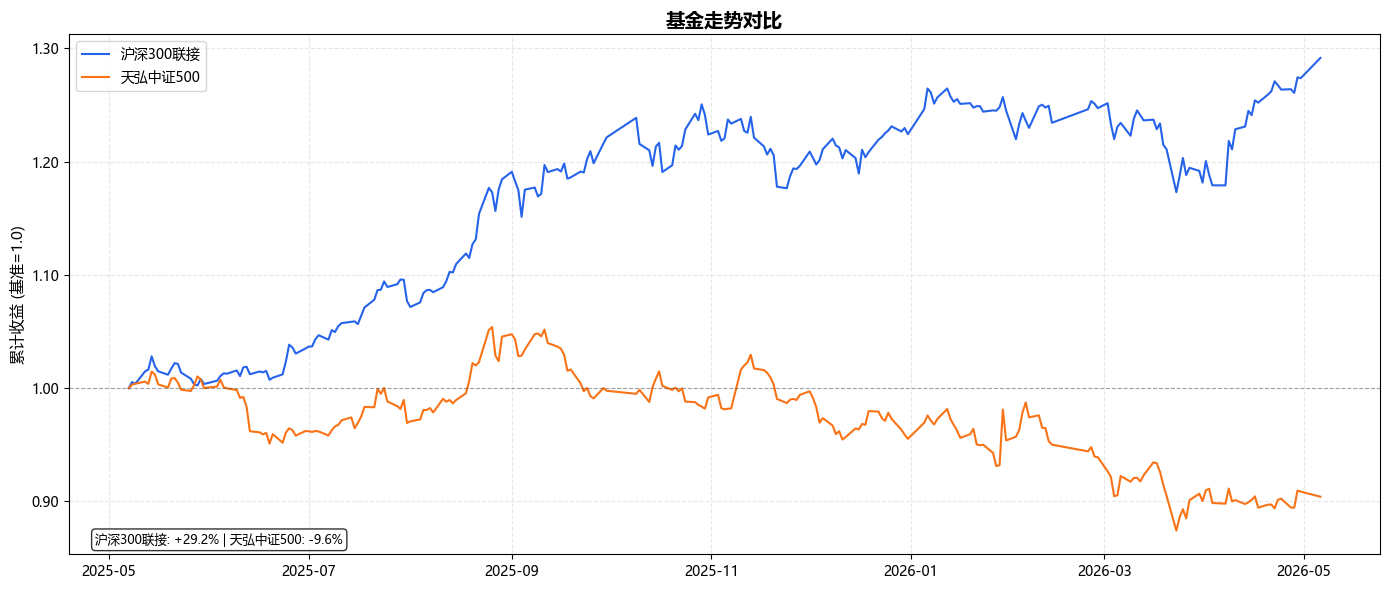

In [11]:
fund_data = {}
for code, name in INTERESTED.items():
    try:
        fund_data[name] = get_fund_nav(code)
    except Exception:
        pass

if len(fund_data) >= 2:
    fig = viz.plot_comparison(fund_data, title="基金走势对比")
    plt.show()
else:
    print("需要至少2只有效基金")

## 4. 深入看风险 — 回撤分析

**最大回撤** 告诉你最坏情况下会亏多少。这是比收益更重要的指标。

关键问题：你能承受这么大的亏损吗？

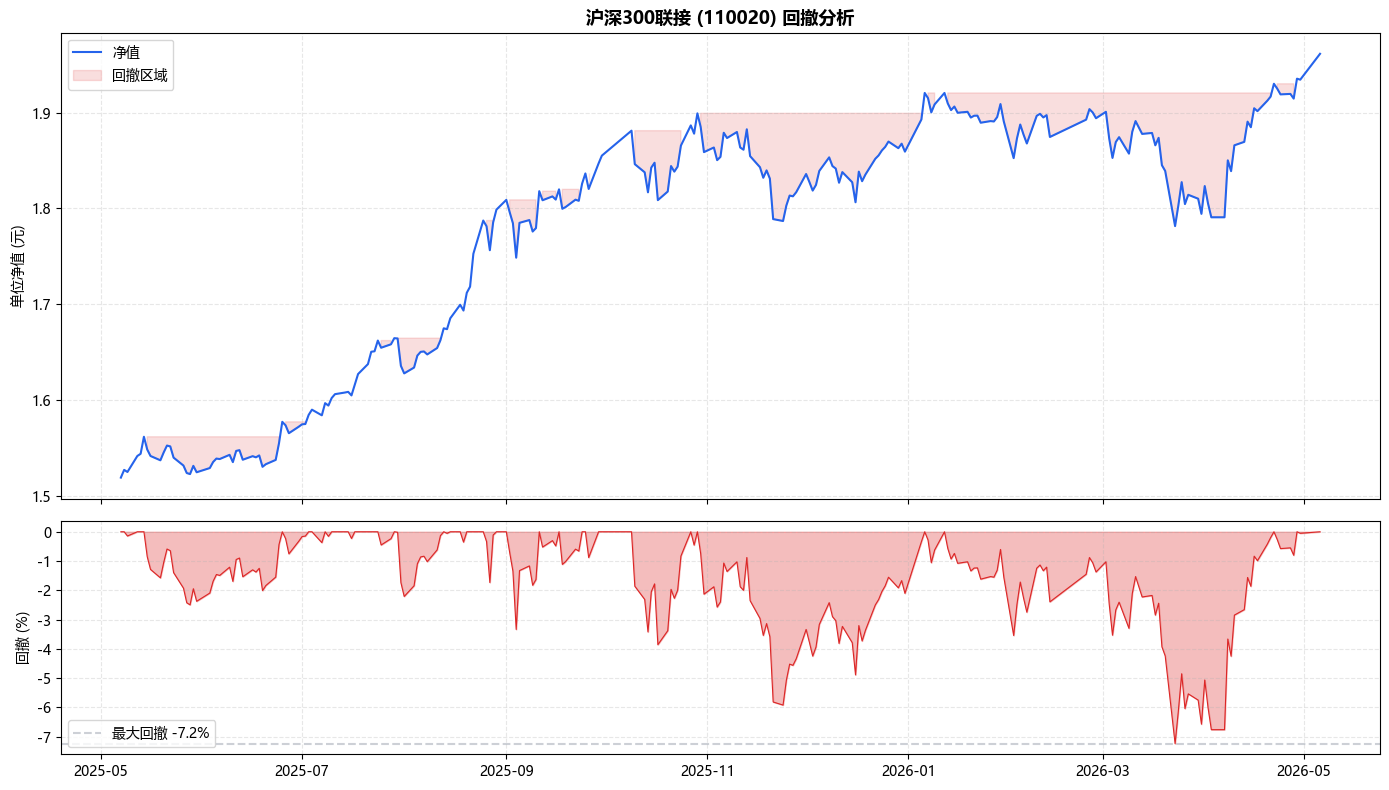

❌ 沪深300联接: 'numpy.int64' object has no attribute 'days'


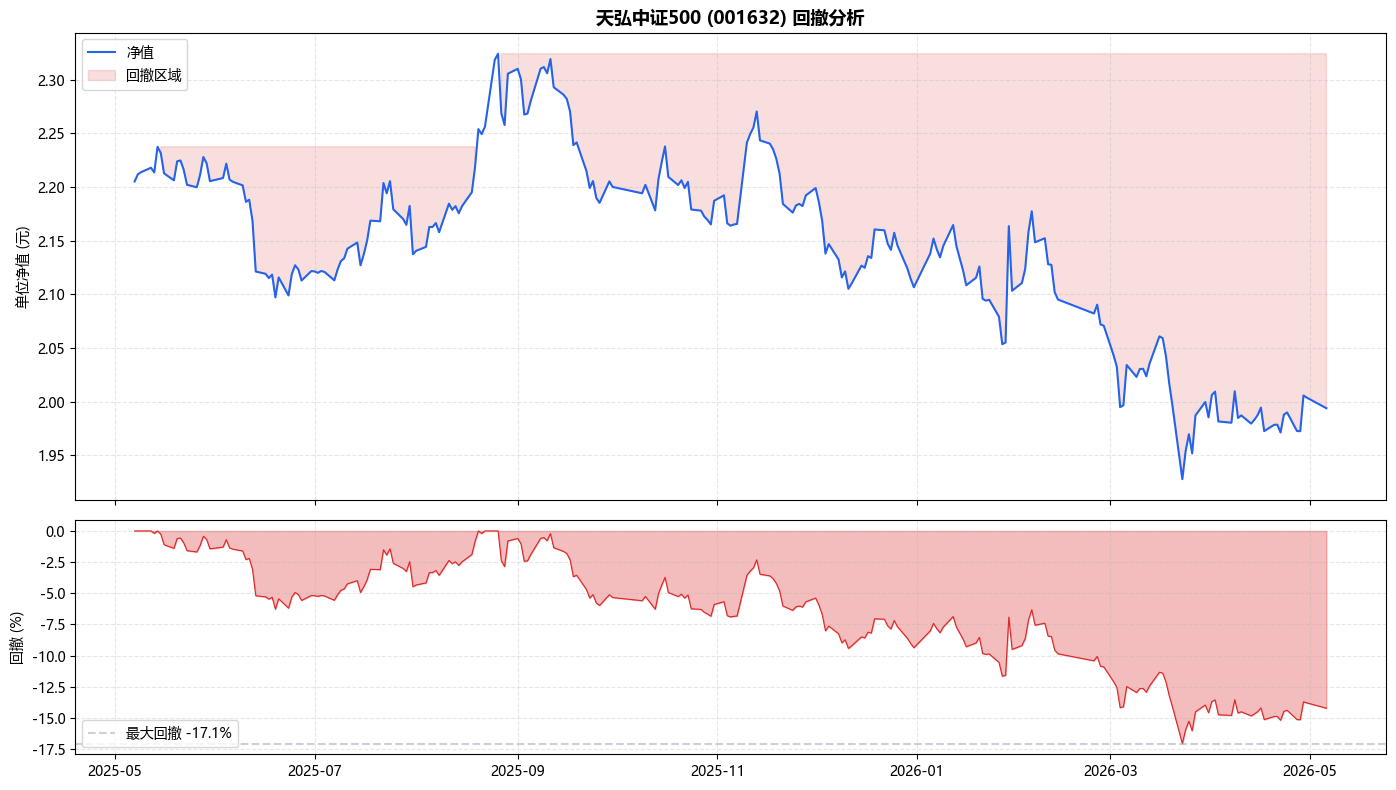

❌ 天弘中证500: 'numpy.int64' object has no attribute 'date'


In [12]:
for code, name in INTERESTED.items():
    try:
        nav = get_fund_nav(code)
        fig = viz.plot_drawdown(nav, title=f"{name} ({code}) 回撤分析")
        plt.show()
        
        dd = max_drawdown(nav["nav"])
        print(f"\n{name}:")
        print(f"  最大回撤: {dd['max_drawdown']}%")
        print(f"  发生时间: {dd['max_dd_start']} ~ {dd['max_dd_end']}")
        print(f"  恢复用了: {dd['recovery_days']} 天")
        print(f"  期间发生 {dd['drawdown_count']} 次回撤")
        print()
    except Exception as e:
        print(f"❌ {name}: {e}")

## 5. 风险-收益散点图

一次看多只基金，找到「收益高、波动低」的基金（左上角区域）。
对角线代表不同的夏普比率水平。

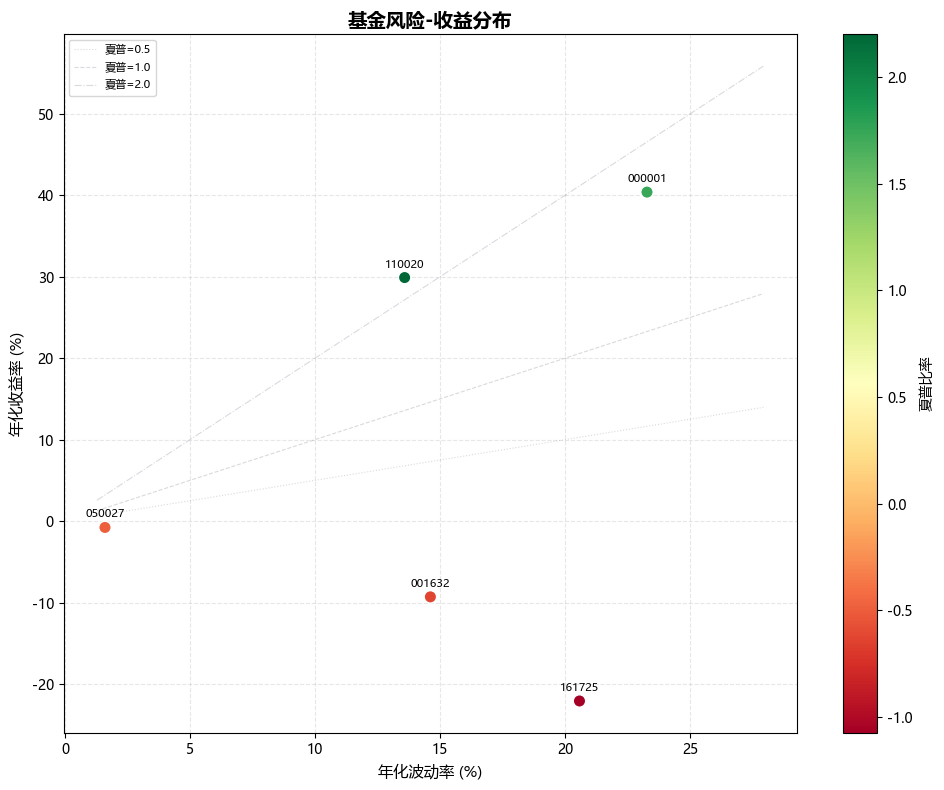


💡 越靠近左上角越好（高收益、低风险）


In [6]:
# 扩展分析更多基金
EXTRA_CODES = ["110020", "001632", "050027", "161725", "000001"]

all_stats = []
for code in EXTRA_CODES:
    try:
        nav = get_fund_nav(code)
        m = calculate_metrics(nav)
        all_stats.append({
            "name": code,
            "annual_return": m["annual_return"],
            "annual_volatility": m["annual_volatility"],
        })
    except Exception:
        pass

if all_stats:
    stats_df = pd.DataFrame(all_stats)
    fig = viz.plot_risk_return_scatter(stats_df, title="基金风险-收益分布")
    plt.show()
    print("\n💡 越靠近左上角越好（高收益、低风险）")

## 6. 风险评估报告

对单只基金做完整的「体检」。

In [7]:
REPORT_CODE = "110020"  # 改成你想检查的基金

report = risk_report(REPORT_CODE)
print(f"\n📋 风险评估报告 — {REPORT_CODE}")
print("="*50)
for k, v in report.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2f}" if k.endswith("days") else f"  {k}: {v:.2f}%")
    else:
        print(f"  {k}: {v}")

print(f"\n解读:")
if report.get("skewness", 0) < -0.5:
    print("  ⚠️ 负偏度明显，暴跌风险大于暴涨机会")
if abs(report.get("max_drawdown", 0)) > 30:
    print("  ⚠️ 最大回撤超过30%，波动较大")
if report.get("VaR_95", 0) < -3:
    print("  ⚠️ VaR显示单日极端亏损可能超过3%")

AttributeError: 'numpy.int64' object has no attribute 'days'

## 7. 相关性检查 — 你买的基金都在同涨同跌吗？

如果持仓基金高度相关，那「分散投资」只是个幻觉。

In [ ]:
from scripts.analysis.correlation import compute_correlation, plot_correlation_heatmap

CHECK_CORR = ["110020", "001632", "050027", "161725"]
corr = compute_correlation(CHECK_CORR)

if not corr.empty:
    display(corr.round(2))
    fig = plot_correlation_heatmap(corr)
    plt.show()
    
    print("\n📊 解读:")
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            val = corr.iloc[i, j]
            level = "⚠️ 极高" if val > 0.85 else ("✅ 适中" if val < 0.7 else "⚡ 偏高")
            print(f"  {corr.columns[i]} vs {corr.columns[j]}: r={val:.2f} {level}")

## 8. 基金筛选器 — 动手实战

设置你的条件，让程序帮你筛选。

In [ ]:
from scripts.analysis.fund_scanner import scan_funds

# 👇 修改这些参数来定制筛选
result = scan_funds(
    fund_type="mix",       # stock/bond/mix/index
    min_return=8,           # 年化收益不低于8%
    max_drawdown=20,        # 最大回撤不超过20%
    min_sharpe=0.5,         # 夏普比率不低于0.5
    top_n=15,               # 返回前15名
)

if not result.empty:
    display(result)
    print(f"\n✅ 找到 {len(result)} 只符合条件的基金")
else:
    print("\n😕 没有完全符合条件的基金，尝试放宽条件")

## 📝 本节小结

你已经学会：
- ✅ 看排名但不追排名
- ✅ 用多个指标（收益+回撤+夏普）评估基金
- ✅ 读懂回撤图，评估自己能否承受
- ✅ 用相关性矩阵检查组合是否真的分散
- ✅ 自定义条件筛选基金

### 新手选基清单

1. 回撤自己能承受吗？（跌 20% 你能睡着吗？）
2. 基金经理干了多久？（< 3 年要谨慎）
3. 基金规模合理吗？（最好 5-100 亿）
4. 费率低吗？（> 1.5% 主动基金多收的钱要赚回来）
5. 和已有持仓相关性高吗？（高就别买了）

### 下一步
📊 打开 `notebooks/03-定投策略回测.ipynb`